Defining the inputs and their formats

In [2]:
input_case = {
    "symptoms": "",
    "doctor_notes": ""
}

Defining the outputs and their formats

In [4]:
output = {
    "similar_case_ids": [],
    "similarity_scores": [],
    "structured_insight_summary": {}
}

Structure of the flow : Diagram 

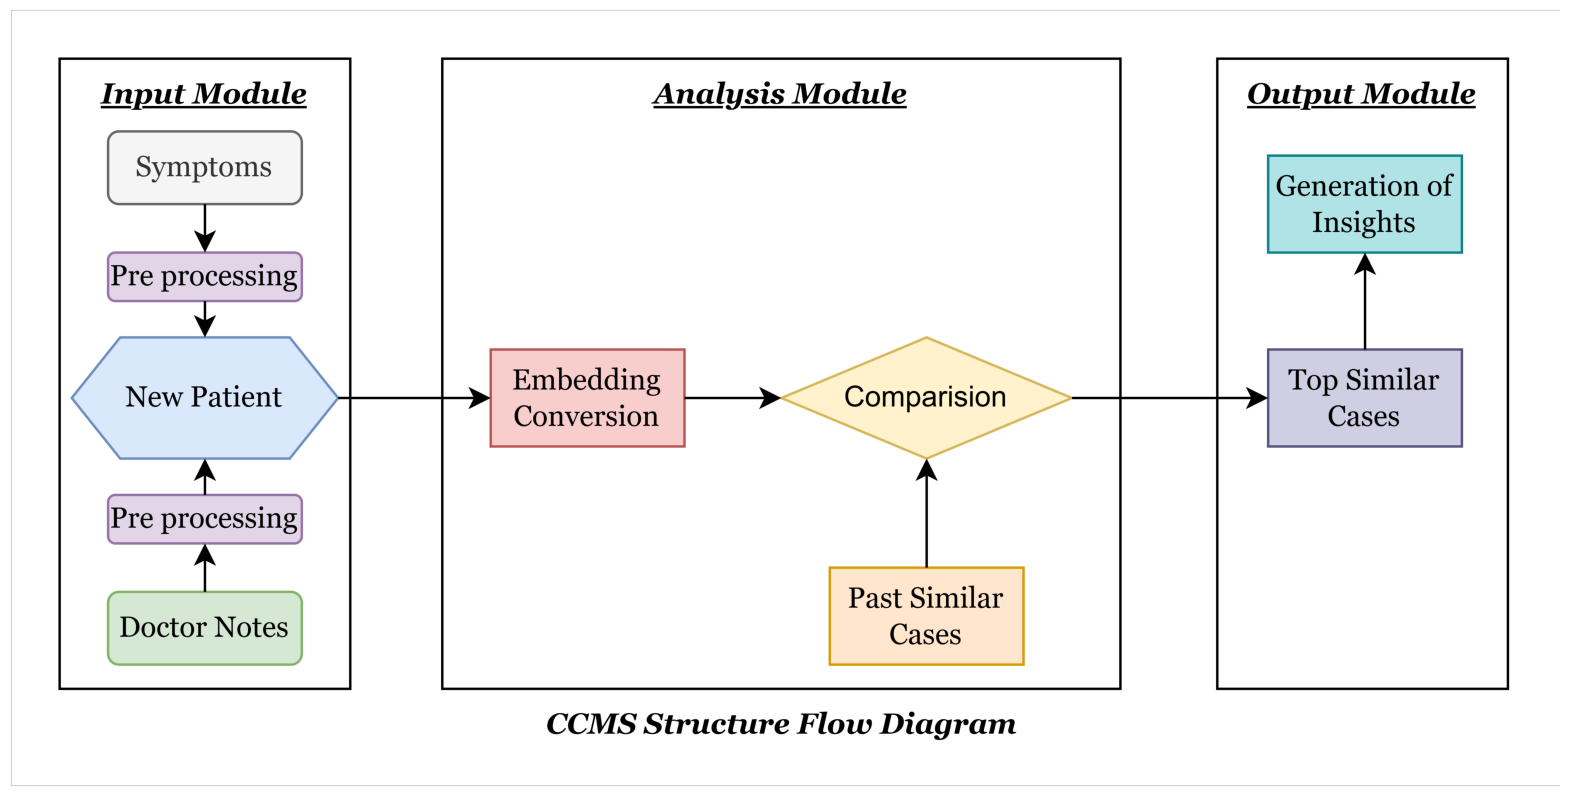

In [12]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
image_path = r"D:\chiselon\Week 3\CCMS  structured flow.png"

# Load image
img = mpimg.imread(image_path)

# Display image
plt.figure(figsize=(20, 16))
plt.imshow(img)
plt.axis('off')  
plt.show()

Explanation of the above Structural Diagram:

-> A New patient is loaded with their (symptoms & doctor note).

-> The Input's are preprocessed before being fed into the network.

-> The pre-processed data is fed to the embedded conversion to convert the text into numerical embeddings.

-> The past similar cases and the new patients embeddings are comapared to find the similarity between them.

-> The top similar cases are collected and displayed.

-> The similar cases which were found are used for generation of insights regarding the patients condition,the likelehood of the disease, whate where the earlier treatment plans etc..

In [15]:
import pandas as pd
import json
import os

FILE_PATH = r"D:\chiselon\Week 0\Week_0_Prep_Week_Ssample Data_clinic_cases.csv"

if not os.path.exists(FILE_PATH):
    raise FileNotFoundError("CSV file not found at given path.")

df = pd.read_csv(FILE_PATH)

print("Dataset Loaded Successfully!")
print("Total Cases:", len(df))
print("Columns:", df.columns.tolist())

# INPUT VALIDATION
def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    return text.lower().strip()


def combine_text(symptoms, doctor_notes):
    symptoms_clean = preprocess_text(symptoms)
    notes_clean = preprocess_text(doctor_notes)
    return symptoms_clean + " " + notes_clean

# EMBEDDING FUNCTION 
def generate_embedding(text):
    """
    Day-1 placeholder embedding.
    Converts text into simple numeric representation.
    """
    text = preprocess_text(text)
    length_feature = len(text)
    char_sum_feature = sum(ord(c) for c in text) % 1000
    
    return [length_feature, char_sum_feature]

# SIMPLE SIMILARITY
def compute_similarity(vec1, vec2):
    """
    Simple similarity placeholder (inverse distance).
    """
    distance = abs(vec1[0] - vec2[0]) + abs(vec1[1] - vec2[1])
    similarity = 1 / (1 + distance)
    return similarity


def retrieve_similar_cases(new_embedding, top_n=5):
    
    similarities = []

    for index, row in df.iterrows():
        
        combined = combine_text(row['symptoms'], row['doctor_notes'])
        case_embedding = generate_embedding(combined)
        
        score = compute_similarity(new_embedding, case_embedding)
        
        similarities.append({
            "case_id": row['case_id'],
            "similarity_score": round(score, 4),
            "treatment": row.get('treatment', "NA"),
            "outcome": row.get('outcome', "NA")
        })
    
    # Sort descending
    similarities = sorted(similarities, key=lambda x: x['similarity_score'], reverse=True)
    
    return similarities[:top_n]

# INSIGHT GENERATION (STRUCTURED OUTPUT)
def generate_case_insight(similar_cases):
    
    treatments = []
    outcomes = []
    
    for case in similar_cases:
        treatments.append(case["treatment"])
        outcomes.append(case["outcome"])
    
    # Most common treatment
    most_common_treatment = max(set(treatments), key=treatments.count)
    
    # Recovery trend
    recovery_count = outcomes.count("Improved")
    recovery_percentage = (recovery_count / len(outcomes)) * 100
    
    insight = {
        "most_common_treatment": most_common_treatment,
        "recovery_trend": f"{round(recovery_percentage,2)}% cases showed improvement",
        "confidence_reason": f"Based on {len(similar_cases)} structurally similar historical cases"
    }
    
    return insight


# COMPLETE PIPELINE
def similarity_engine_pipeline(symptoms, doctor_notes):
    
    combined_text = combine_text(symptoms, doctor_notes)
    new_embedding = generate_embedding(combined_text)
    
    similar_cases = retrieve_similar_cases(new_embedding, top_n=5)
    
    insight = generate_case_insight(similar_cases)
    
    output = {
        "similar_cases": similar_cases,
        "insight_summary": insight
    }
    
    return output

if __name__ == "__main__":
    
    new_symptoms = "Severe chest pain radiating to arm"
    new_notes = "Patient sweating and breathless. Known hypertension."
    
    result = similarity_engine_pipeline(new_symptoms, new_notes)
    
    print("\n=== CCMS Similarity Engine Output (Day-1 Blueprint) ===\n")
    print(json.dumps(result, indent=4))

Dataset Loaded Successfully!
Total Cases: 10
Columns: ['case_id', 'clinic_id', 'symptoms', 'duration_days', 'doctor_notes', 'diagnosis', 'treatment', 'outcome', 'recovery_days', 'patient.age', 'patient.gender']

=== CCMS Similarity Engine Output (Day-1 Blueprint) ===

{
    "similar_cases": [
        {
            "case_id": "CASE_008",
            "similarity_score": 0.0161,
            "treatment": "Laser evaluation",
            "outcome": "Referred"
        },
        {
            "case_id": "CASE_002",
            "similarity_score": 0.0139,
            "treatment": "Topical steroid + antihistamine",
            "outcome": "Improved"
        },
        {
            "case_id": "CASE_004",
            "similarity_score": 0.013,
            "treatment": "Topical tacrolimus",
            "outcome": "No Change"
        },
        {
            "case_id": "CASE_009",
            "similarity_score": 0.0041,
            "treatment": "Oral antibiotics",
            "outcome": "Improved"


WITH A NEW GENERATED PATIENT : THE ANALYSIS 

In [18]:
FILE_PATH = r"D:\chiselon\Week 0\Week_0_Prep_Week_Ssample Data_clinic_cases.csv"

if not os.path.exists(FILE_PATH):
    raise FileNotFoundError("CSV file not found at given path.")

df = pd.read_csv(FILE_PATH)

print("Dataset Loaded Successfully!")
print("Total Cases:", len(df))
print("Columns:", df.columns.tolist())

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    return text.lower().strip()


def combine_text(symptoms, doctor_notes, diagnosis):
    
    return (
        preprocess_text(symptoms) + " " +
        preprocess_text(doctor_notes) + " " +
        preprocess_text(diagnosis)
    )

# SIMPLE PLACEHOLDER EMBEDDING (DAY-1 STRUCTURE)
def generate_embedding(text):
    text = preprocess_text(text)
    length_feature = len(text)
    char_sum_feature = sum(ord(c) for c in text) % 1000
    return [length_feature, char_sum_feature]

# SIMPLE SIMILARITY FUNCTION
def compute_similarity(vec1, vec2):
    distance = abs(vec1[0] - vec2[0]) + abs(vec1[1] - vec2[1])
    similarity = 1 / (1 + distance)
    return similarity

# RETRIEVE SIMILAR CASES (CHECKS EACH PATIENT)
def retrieve_similar_cases(new_embedding, top_n=5):

    similarities = []

    for index, row in df.iterrows():

        combined_text = combine_text(
            row["symptoms"],
            row["doctor_notes"],
            row["diagnosis"]
        )

        case_embedding = generate_embedding(combined_text)

        score = compute_similarity(new_embedding, case_embedding)

        similarities.append({
            "case_id": row["case_id"],
            "diagnosis": row["diagnosis"],
            "treatment": row["treatment"],
            "outcome": row["outcome"],
            "similarity_score": round(score, 5)
        })

    similarities = sorted(similarities,
                          key=lambda x: x["similarity_score"],
                          reverse=True)

    return similarities[:top_n]

# INSIGHT GENERATION
def generate_case_insight(similar_cases):

    treatments = [case["treatment"] for case in similar_cases]
    outcomes = [case["outcome"] for case in similar_cases]

    most_common_treatment = max(set(treatments), key=treatments.count)

    improved_count = outcomes.count("Improved")
    improvement_rate = (improved_count / len(outcomes)) * 100

    insight = {
        "most_common_treatment": most_common_treatment,
        "improvement_rate": f"{round(improvement_rate,2)}%",
        "confidence_reason":
            f"Based on {len(similar_cases)} structurally similar historical cases"
    }

    return insight

# COMPLETE PIPELINE
def similarity_engine_pipeline(new_patient):

    combined_new = combine_text(
        new_patient["symptoms"],
        new_patient["doctor_notes"],
        new_patient["diagnosis"]
    )

    new_embedding = generate_embedding(combined_new)

    similar_cases = retrieve_similar_cases(new_embedding)

    insight = generate_case_insight(similar_cases)

    output = {
        "new_patient": new_patient,
        "similar_cases": similar_cases,
        "insight_summary": insight
    }

    return output

# GENERATE A NEW PATIENT (TEST CASE)
new_patient = {
    "symptoms": "Itching and skin redness",
    "doctor_notes": "Patient reports mild irritation for 10 days",
    "diagnosis": "Possible Contact Dermatitis"
}
result = similarity_engine_pipeline(new_patient)

print("\n=== CCMS Similarity Engine Output (Day-1 Blueprint) ===\n")
print(json.dumps(result, indent=4))

Dataset Loaded Successfully!
Total Cases: 10
Columns: ['case_id', 'clinic_id', 'symptoms', 'duration_days', 'doctor_notes', 'diagnosis', 'treatment', 'outcome', 'recovery_days', 'patient.age', 'patient.gender']

=== CCMS Similarity Engine Output (Day-1 Blueprint) ===

{
    "new_patient": {
        "symptoms": "Itching and skin redness",
        "doctor_notes": "Patient reports mild irritation for 10 days",
        "diagnosis": "Possible Contact Dermatitis"
    },
    "similar_cases": [
        {
            "case_id": "CASE_002",
            "diagnosis": "Contact Dermatitis",
            "treatment": "Topical steroid + antihistamine",
            "outcome": "Improved",
            "similarity_score": 0.00877
        },
        {
            "case_id": "CASE_004",
            "diagnosis": "Vitiligo",
            "treatment": "Topical tacrolimus",
            "outcome": "No Change",
            "similarity_score": 0.00704
        },
        {
            "case_id": "CASE_005",
         